In [1]:
# ==============================================================================
# 1. LÉPÉS: Egyetlen valós frame letöltése a hivatalos KITTI adattárból
# ==============================================================================
import os
import urllib.request
import zipfile
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Letöltünk egy szinkronizált KITTI szekvenciát és a kalibrációt (~40 MB)
base_url = "https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/2011_09_26_drive_0009/"
data_zip = "2011_09_26_drive_0009_sync.zip"
calib_zip = "2011_09_26_calib.zip"

if not os.path.exists(data_zip):
  print("KITTI frame-ek letöltése...")
  urllib.request.urlretrieve(base_url + data_zip, data_zip)
  urllib.request.urlretrieve(
      "https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/" + calib_zip,
      calib_zip,
  )

  with zipfile.ZipFile(data_zip, "r") as z:
    z.extractall(".")
  with zipfile.ZipFile(calib_zip, "r") as z:
    z.extractall(".")
  print("Letöltés kész!")

KITTI frame-ek letöltése...
Letöltés kész!


In [4]:

# ==============================================================================
# 2. LÉPÉS: Kalibrációs fájlok beolvasása és mátrixok felépítése
# ==============================================================================
def read_calib_file(filepath):
  data = {}
  with open(filepath, "r") as f:
    for line in f.readlines():
      if ":" in line:
        key, value = line.split(":", 1)
        value_str_list = value.strip().split()

        # Check if all elements in value_str_list can be converted to float
        all_numeric = True
        float_values = []
        for x in value_str_list:
            try:
                float_values.append(float(x))
            except ValueError:
                all_numeric = False
                break

        if all_numeric and float_values: # Only add if all are numeric and not empty
            data[key.strip()] = np.array(float_values)
  return data


# Kalibrációs mátrixok betöltése
calib_cam = read_calib_file("2011_09_26/calib_cam_to_cam.txt")
calib_velo = read_calib_file("2011_09_26/calib_velo_to_cam.txt")

# 1. Extrinsic: LiDAR -> Kamera 0 (Tr_velo_to_cam)
R_v2c = calib_velo["R"].reshape(3, 3)
T_v2c = calib_velo["T"].reshape(3, 1)
Tr_velo_to_cam = np.eye(4)
Tr_velo_to_cam[:3, :3] = R_v2c
Tr_velo_to_cam[:3, 3] = T_v2c.flatten()

# 2. Kamera 2 (Színes bal kamera) Intrinsic és Torzítás paraméterei
K_cam2 = calib_cam["K_02"].reshape(3, 3)  # Nyers belső mátrix
D_cam2 = calib_cam["D_02"]  # 5 paraméteres torzítás (k1, k2, p1, p2, k3)
R_rect2 = calib_cam["R_rect_02"].reshape(3, 3)  # Rektifikációs forgatás
P_rect2 = calib_cam["P_rect_02"].reshape(
    3, 4
)  # Hivatalos rektifikált projekciós mátrix

# R_rect homogén alakban
R_rect_homo = np.eye(4)
R_rect_homo[:3, :3] = R_rect2


In [5]:

# ==============================================================================
# 3. LÉPÉS: Képek és Pontfelhő beolvasása (0. frame)
# ==============================================================================
drive_path = "2011_09_26/2011_09_26_drive_0009_sync/"

# Nyers (torzított) és már rektifikált kép betöltése
img_raw_path = (
    drive_path + "image_02/data/0000000000.png"
)  # A KITTI sync könyvtárában ez az alap kép
img_raw = cv2.imread(img_raw_path)
h, w, _ = img_raw.shape

# LiDAR pontfelhő betöltése (x, y, z, reflectance)
lidar_path = drive_path + "velodyne_points/data/0000000000.bin"
scan = np.fromfile(lidar_path, dtype=np.float32).reshape((-1, 4))
lidar_pts = scan[:, :3]  # Csak a 3D koordináták (N, 3)


In [6]:

# ==============================================================================
# 4. LÉPÉS: 3D -> 2D Projekciós függvények
# ==============================================================================
# Homogén koordináták képzése (N, 4)
pts_homo = np.hstack([lidar_pts, np.ones((len(lidar_pts), 1))])

# 1. Transzformáció a referencia kamera térbe: P_cam = Tr_velo_to_cam @ P_lidar
pts_cam_ref = (Tr_velo_to_cam @ pts_homo.T).T

# --- A) Hibás / Nyers vetítés (Nem vettük figyelembe a lencsetorzítást & rektifikálást) ---
# Csak az elöl lévő pontokat tartjuk meg (Z > 0)
mask_front = pts_cam_ref[:, 2] > 1.0
pts_front_raw = pts_cam_ref[mask_front]

# Egyszerű Pinhole vetítés a nyers K mátrixszal
u_raw = (
    K_cam2[0, 0] * (pts_front_raw[:, 0] / pts_front_raw[:, 2]) + K_cam2[0, 2]
)
v_raw = (
    K_cam2[1, 1] * (pts_front_raw[:, 1] / pts_front_raw[:, 2]) + K_cam2[1, 2]
)
depth_raw = pts_front_raw[:, 2]

# --- B) Helyes vetítés (Rektifikált térbe vetítés a P_rect2 mátrixszal) ---
# P_rect = P_rect2 @ R_rect_homo @ Tr_velo_to_cam @ P_lidar
pts_rect_proj = (P_rect2 @ R_rect_homo @ Tr_velo_to_cam @ pts_homo.T).T
mask_front_rect = pts_rect_proj[:, 2] > 1.0
pts_rect_proj = pts_rect_proj[mask_front_rect]

u_rect = pts_rect_proj[:, 0] / pts_rect_proj[:, 2]
v_rect = pts_rect_proj[:, 1] / pts_rect_proj[:, 2]
depth_rect = pts_rect_proj[:, 2]

# Szoftveres torztalanítás OpenCV-vel a nyers képen
img_undistorted = cv2.undistort(img_raw, K_cam2, D_cam2)


/tmp/ipykernel_2067/3998545781.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("jet")
/tmp/ipykernel_2067/3998545781.py:40: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2067/3998545781.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


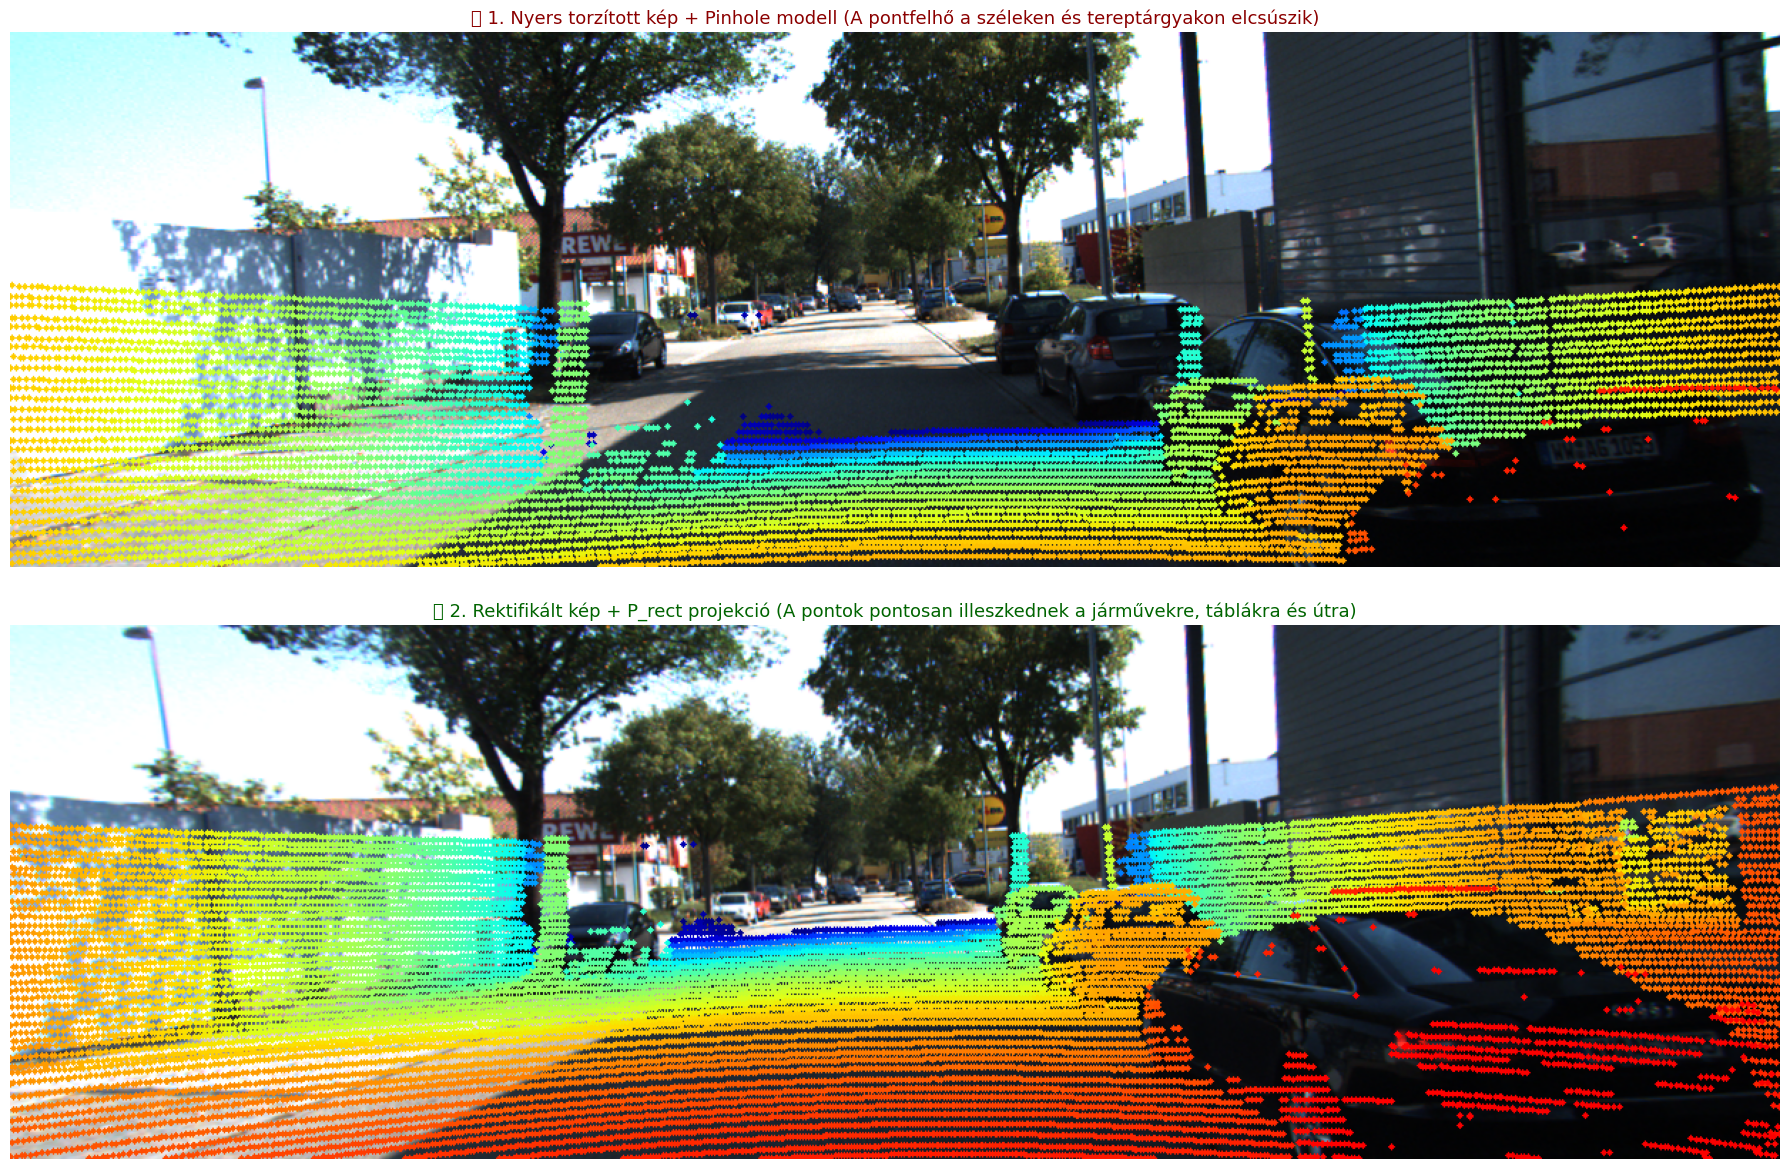

In [7]:

# ==============================================================================
# 5. LÉPÉS: Vizualizáció és összehasonlítás
# ==============================================================================
fig, axes = plt.subplots(2, 1, figsize=(18, 12))


# Helper a pontfelhő rárajzolásához mélység szerinti színezéssel (Jet colormap)
def draw_points(image, u, v, depth):
  img_out = image.copy()
  cmap = plt.cm.get_cmap("jet")
  for px, py, d in zip(u.astype(int), v.astype(int), depth):
    if 0 <= px < w and 0 <= py < h and d < 40:  # 40 méteren belül
      color = tuple(np.array(cmap(d / 40.0)[:3]) * 255)
      cv2.circle(img_out, (px, py), 2, color, -1)
  return img_out


# 1. Nyers kép + Direkt vetítés
overlay_raw = draw_points(img_raw, u_raw, v_raw, depth_raw)
axes[0].imshow(cv2.cvtColor(overlay_raw, cv2.COLOR_BGR2RGB))
axes[0].set_title(
    "❌ 1. Nyers torzított kép + Pinhole modell (A pontfelhő a széleken és"
    " tereptárgyakon elcsúszik)",
    fontsize=13,
    color="darkred",
)
axes[0].axis("off")

# 2. Rektifikált kép + Kalibrált projekció
overlay_rect = draw_points(img_undistorted, u_rect, v_rect, depth_rect)
axes[1].imshow(cv2.cvtColor(overlay_rect, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    "✅ 2. Rektifikált kép + P_rect projekció (A pontok pontosan illeszkednek a"
    " járművekre, táblákra és útra)",
    fontsize=13,
    color="darkgreen",
)
axes[1].axis("off")

plt.tight_layout()
plt.show()
